In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)
print("\nMatches columns:", matches.columns.tolist())
print("\nDeliveries columns:", deliveries.columns.tolist())

Matches shape: (1095, 20)
Deliveries shape: (260920, 17)

Matches columns: ['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

Deliveries columns: ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [3]:
print("=== MATCHES ===")
print(matches.head())
print("\nMissing values in matches:")
print(matches.isnull().sum()[matches.isnull().sum() > 0])

print("\n=== DELIVERIES ===")
print(deliveries.head())
print("\nMissing values in deliveries:")
print(deliveries.isnull().sum()[deliveries.isnull().sum() > 0])

=== MATCHES ===
       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla             Delhi Daredevils   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens        Kolkata Knight Riders   

                         team2                  toss_winner toss_decision  \

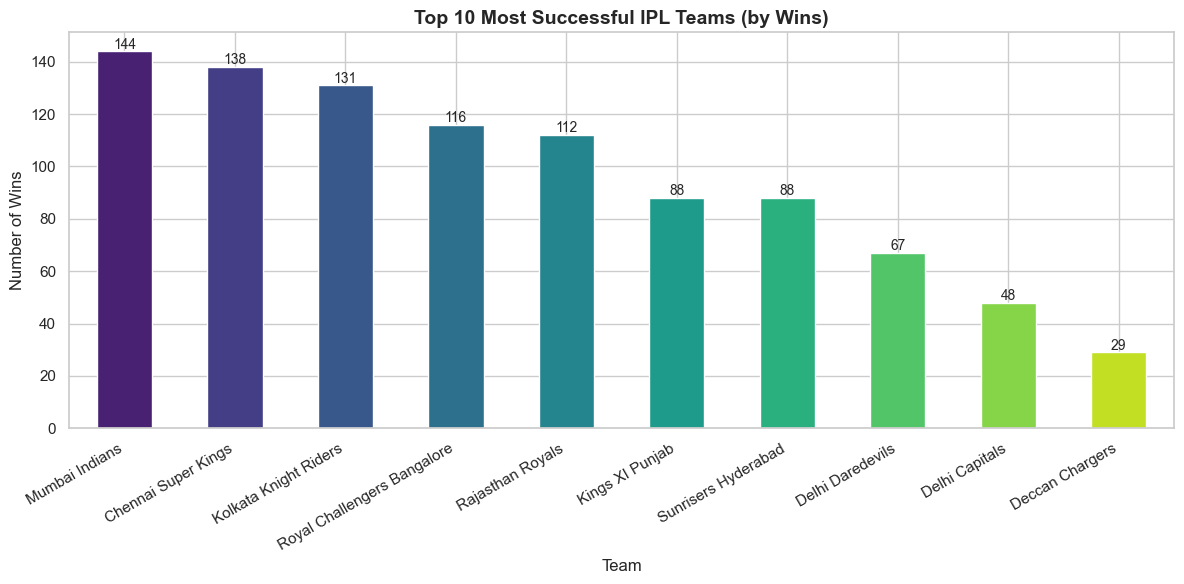

In [4]:
team_wins = matches['winner'].value_counts().head(10)

fig, ax = plt.subplots()
team_wins.plot(kind='bar', color=sns.color_palette('viridis', 10),
               edgecolor='white', ax=ax)
ax.set_title('Top 10 Most Successful IPL Teams (by Wins)', fontsize=14, fontweight='bold')
ax.set_xlabel('Team')
ax.set_ylabel('Number of Wins')
ax.set_xticklabels(team_wins.index, rotation=30, ha='right')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height() + 1),
                ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('team_wins.png', dpi=150)
plt.show()

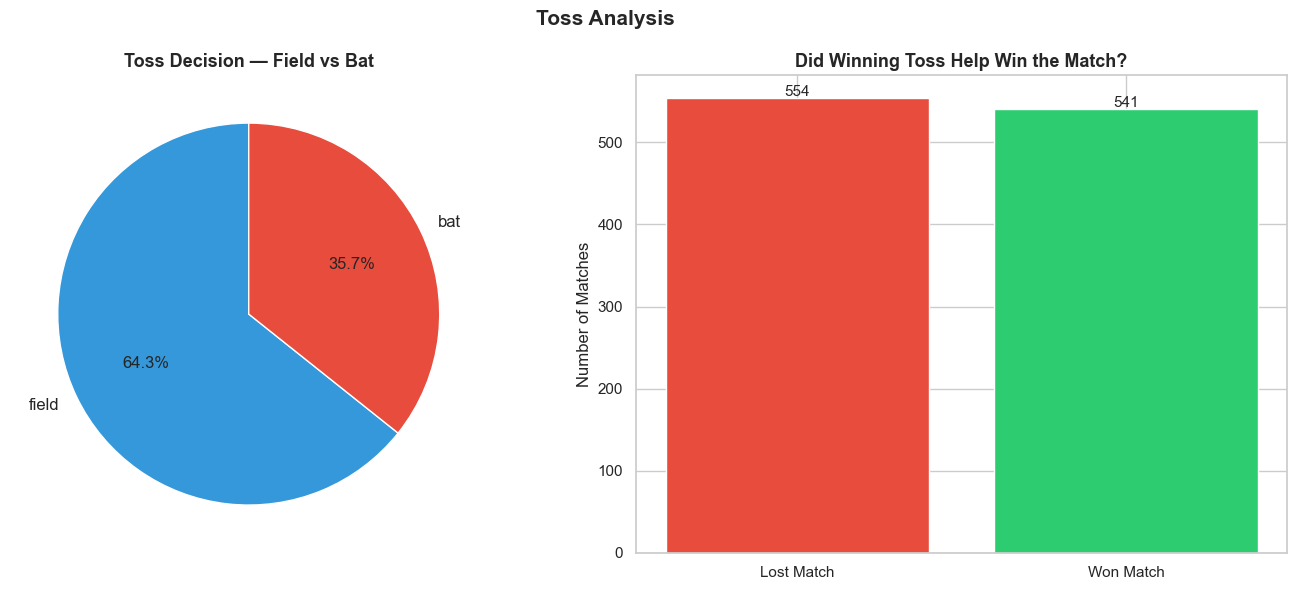

In [5]:
toss_decision = matches['toss_decision'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# pie chart — toss decision split
axes[0].pie(toss_decision.values, labels=toss_decision.index,
            autopct='%1.1f%%', colors=['#3498DB', '#E74C3C'],
            startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Toss Decision — Field vs Bat', fontsize=13, fontweight='bold')

# did winning toss help win the match?
matches['toss_match_winner'] = matches['toss_winner'] == matches['winner']
toss_win = matches['toss_match_winner'].value_counts()
axes[1].bar(['Lost Match', 'Won Match'], toss_win.values,
            color=['#E74C3C', '#2ECC71'], edgecolor='white')
axes[1].set_title('Did Winning Toss Help Win the Match?', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Matches')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 2),
                     ha='center', fontsize=11)

plt.suptitle('Toss Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('toss_analysis.png', dpi=150)
plt.show()

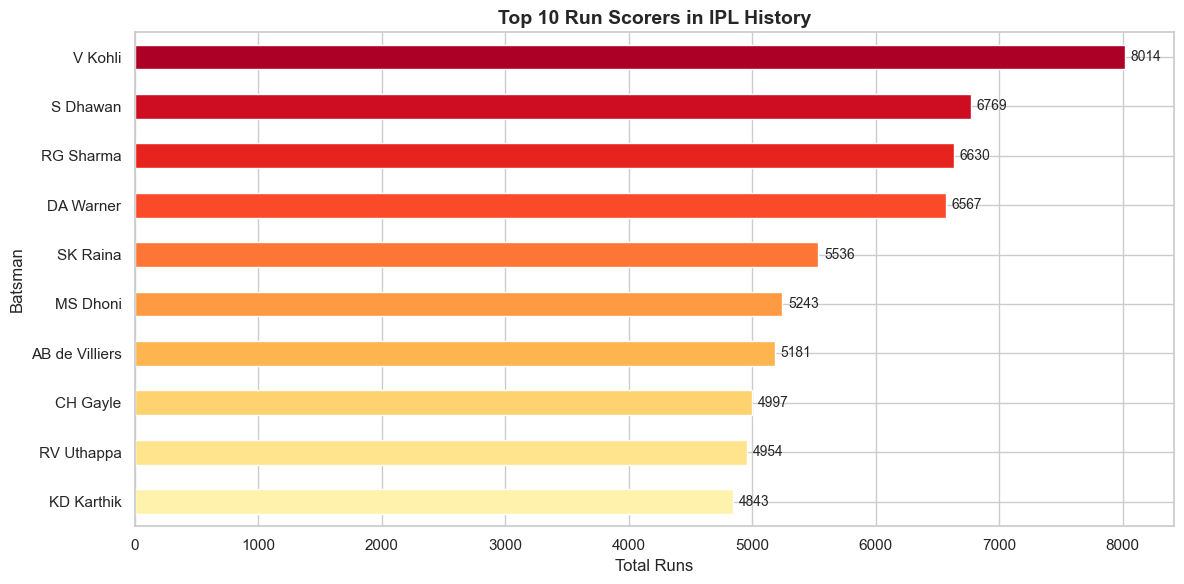

In [6]:
top_batsmen = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots()
colors = sns.color_palette('YlOrRd', 10)[::-1]
top_batsmen.plot(kind='barh', color=colors, edgecolor='white', ax=ax)
ax.set_title('Top 10 Run Scorers in IPL History', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Runs')
ax.set_ylabel('Batsman')
ax.invert_yaxis()
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width() + 50, p.get_y() + p.get_height()/2),
                va='center', fontsize=10)
plt.tight_layout()
plt.savefig('top_batsmen.png', dpi=150)
plt.show()

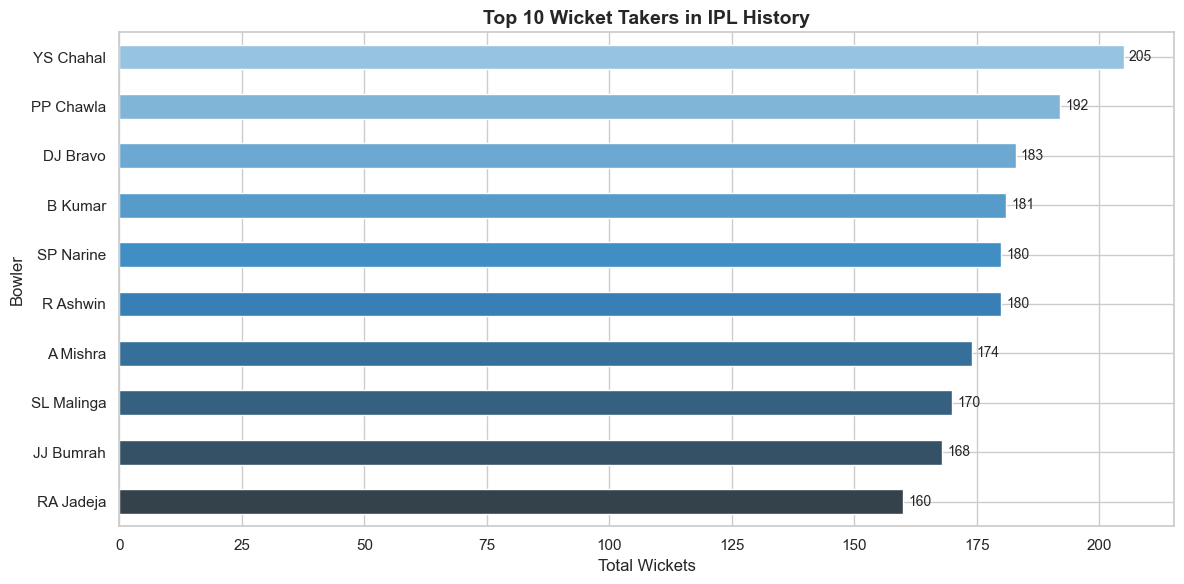

In [7]:
# exclude non-bowled dismissals
valid_wickets = deliveries[deliveries['dismissal_kind'].notna() &
                           ~deliveries['dismissal_kind'].isin(['run out', 'retired hurt', 'obstructing the field'])]

top_bowlers = valid_wickets.groupby('bowler')['is_wicket'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots()
colors = sns.color_palette('Blues_d', 10)
top_bowlers.plot(kind='barh', color=colors, edgecolor='white', ax=ax)
ax.set_title('Top 10 Wicket Takers in IPL History', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Wickets')
ax.set_ylabel('Bowler')
ax.invert_yaxis()
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width() + 1, p.get_y() + p.get_height()/2),
                va='center', fontsize=10)
plt.tight_layout()
plt.savefig('top_bowlers.png', dpi=150)
plt.show()

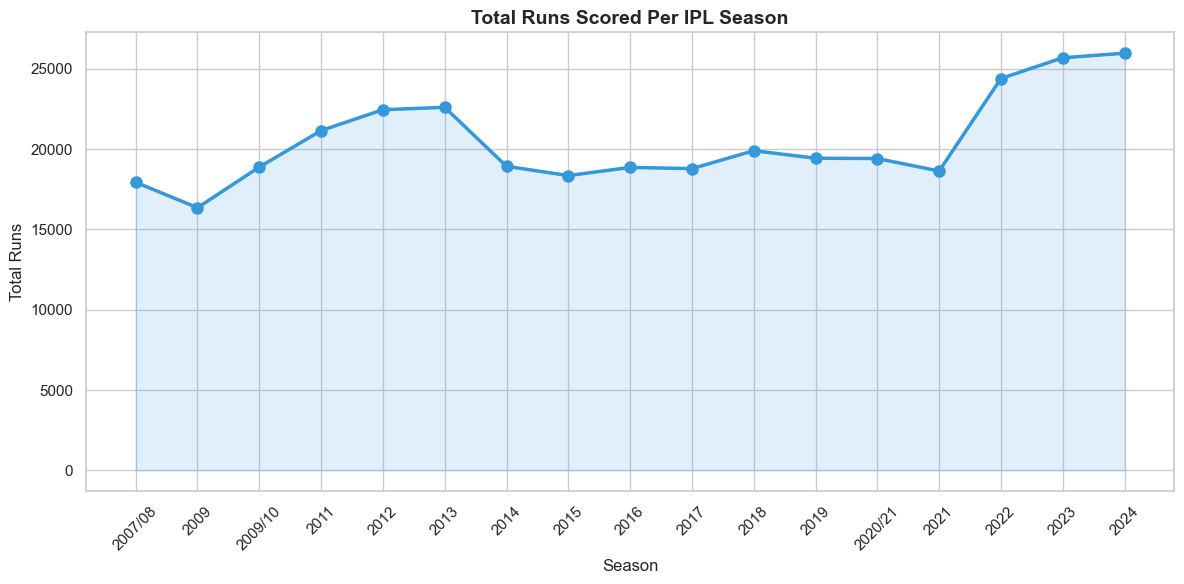

In [8]:
# merge deliveries with matches to get season info
deliveries_with_season = deliveries.merge(matches[['id', 'season']], 
                                           left_on='match_id', right_on='id')

runs_per_season = deliveries_with_season.groupby('season')['total_runs'].sum().reset_index()

fig, ax = plt.subplots()
ax.plot(runs_per_season['season'], runs_per_season['total_runs'],
        color='#3498DB', linewidth=2.5, marker='o', markersize=8)
ax.fill_between(runs_per_season['season'], runs_per_season['total_runs'],
                alpha=0.15, color='#3498DB')
ax.set_title('Total Runs Scored Per IPL Season', fontsize=14, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Total Runs')
ax.set_xticks(runs_per_season['season'])
ax.set_xticklabels(runs_per_season['season'], rotation=45)
plt.tight_layout()
plt.savefig('runs_per_season.png', dpi=150)
plt.show()


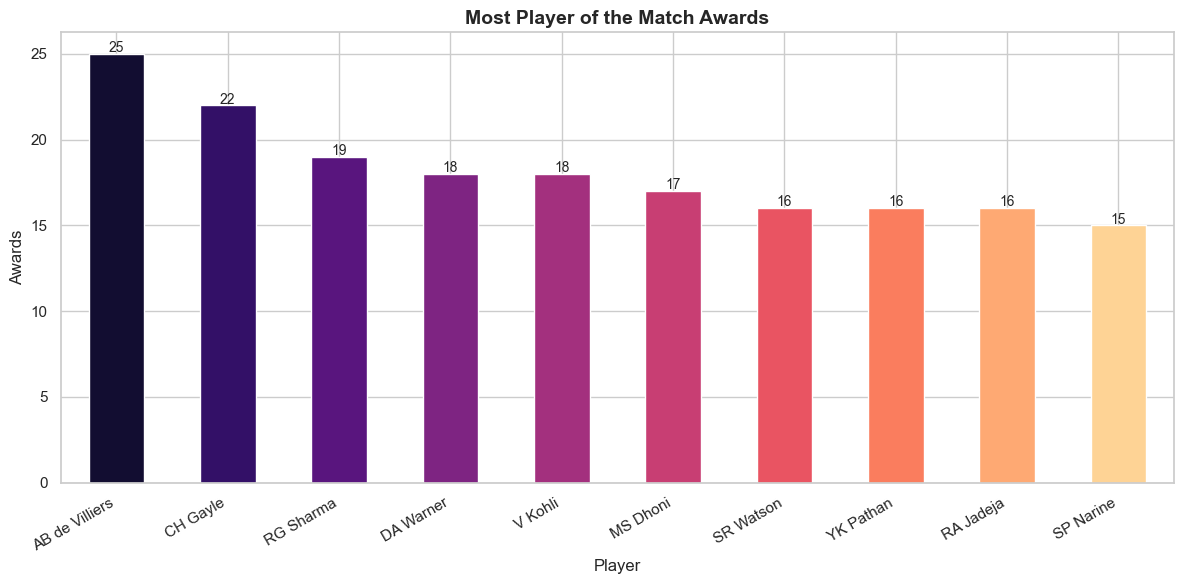

In [9]:
potm = matches['player_of_match'].value_counts().head(10)

fig, ax = plt.subplots()
potm.plot(kind='bar', color=sns.color_palette('magma', 10),
          edgecolor='white', ax=ax)
ax.set_title('Most Player of the Match Awards', fontsize=14, fontweight='bold')
ax.set_xlabel('Player')
ax.set_ylabel('Awards')
ax.set_xticklabels(potm.index, rotation=30, ha='right')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height() + 0.1),
                ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('player_of_match.png', dpi=150)
plt.show()

## Key Findings

1. **Mumbai Indians are the most successful team** — highest number of wins across all IPL seasons.
2. **Fielding first is the preferred toss decision** — majority of captains choose to field after winning the toss.
3. **Winning the toss has minimal impact** — toss winners and losers win matches at nearly equal rates.
4. **Virat Kohli is the all-time leading run scorer** — ahead of all other batsmen by a significant margin.
5. **Total runs per season have increased** — batting has become more aggressive over the years.
6. **AB de Villiers dominates Player of the Match** — consistent match-winning performances across seasons.